In [1]:
# Colab용 단계별 실행 코드
# 목적:
# 1) OpenAI API 키 불러오기
# 2) 엑셀 읽기 + 이미지 경로 점검
# 3) 라벨 기준 텍스트 세팅
# 4) 소수 샘플로 GPT와 대화형 테스트
# 5) 이후 전체 배치 라벨링으로 확장할 수 있게 설계
#
# 사용 전 준비:
# - candidate_metrics_bedall.xlsx 파일 경로 확인
# - 이미지가 들어있는 루트 폴더 경로 확인
# - OpenAI API key 준비
#
# 권장 실행 순서:
# 셀 1 -> 셀 2 -> 셀 3 ... 순서대로 나눠서 실행

# =========================================================
# 셀 1. 패키지 설치
# =========================================================
!pip uninstall -y pillow
!pip -q install --upgrade openai pandas openpyxl pillow tqdm


# =========================================================
# 셀 2. 기본 import
# =========================================================
import os
import json
import time
import base64
from pathlib import Path

import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from openai import OpenAI


# =========================================================
# 셀 3. 경로 설정
# 여기를 먼저 네 환경에 맞게 수정
# =========================================================
EXCEL_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/candidate_metrics_bedall.xlsx"
IMAGE_ROOT = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/vis_core_candidate"
OUTPUT_XLSX = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/candidate_metrics_bedall_gpt_test_v2.xlsx"

# 엑셀에서 이미지 상대경로/파일명이 들어있는 열 이름
# 예시: image_path, file_name, img_name 등
IMAGE_COL = "file_name"

# 샘플 테스트 개수
TEST_N = 5

# 사용할 모델
MODEL_NAME = "gpt-5-mini"

Found existing installation: pillow 11.3.0
Uninstalling pillow-11.3.0:
  Successfully uninstalled pillow-11.3.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 143.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pi

In [2]:

# =========================================================
# 셀 4. API 키 불러오기
# 방법 A, B 중 하나만 사용
# =========================================================

# 방법 A) Colab Secrets / 환경변수에 저장해둔 경우
# os.environ["OPENAI_API_KEY"] = "sk-..."

# 방법 B) 실행 시 직접 입력
from getpass import getpass
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key 입력: ")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
print("OpenAI client 준비 완료")



OpenAI API Key 입력: ··········
OpenAI client 준비 완료


In [3]:
# =========================================================
# 셀 5. 엑셀 읽기
# =========================================================
df = pd.read_excel(EXCEL_PATH, sheet_name="candidate_metrics_bedall")
print("shape:", df.shape)
display(df.head(3))
print("columns:")
print(df.columns.tolist())


# =========================================================
# 셀 6. 이미지 경로 생성 함수
# 엑셀의 IMAGE_COL 값이
# - 상대경로일 수도 있고
# - 파일명만 있을 수도 있고
# - 절대경로일 수도 있으니 보정
# =========================================================
def resolve_image_path(row, image_col=IMAGE_COL, image_root=IMAGE_ROOT):
    val = str(row[image_col]).strip()
    if os.path.isabs(val):
        return val
    return str(Path(image_root) / val)

# 이미지 파일명 접미사 추가 (엑셀 파일명과 실제 파일명 불일치 수정)
df[IMAGE_COL] = df[IMAGE_COL].apply(lambda x: x if "__core_candidate.png" in str(x) else str(os.path.splitext(x)[0]) + "__core_candidate" + str(os.path.splitext(x)[1]))

df["resolved_image_path"] = df.apply(resolve_image_path, axis=1)
df["image_exists"] = df["resolved_image_path"].apply(lambda p: os.path.exists(p))

print(df[[IMAGE_COL, "resolved_image_path", "image_exists"]].head(10))
print("존재하는 이미지 수:", int(df["image_exists"].sum()))
print("없는 이미지 수:", int((~df["image_exists"]).sum()))

shape: (1088, 62)


,file_path,file_name,parent_folder,bed_num,orig_h,orig_w,work_h,work_w,resize_scale,mask_area_px,...,top1_top3_gap,confidence_auto,candidate_x_orig,candidate_y_orig,core_lab_2class,core_label,candidate_type,core_strength,memo,vis_path
0,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251214_061656_cam2_b3_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,399,373,399,373,1,94483,...,0.017970,0.673342,185,194,1,2,2,1,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...
1,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251214_061656_cam2_b4_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,381,376,381,376,1,92781,...,0.035004,0.694646,217,236,1,2,2,1,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...
2,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251214_061656_cam2_b5_p01.png,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,418,343,418,343,1,90789,...,0.048009,0.713338,166,211,1,2,3,1,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...


columns:
['file_path', 'file_name', 'parent_folder', 'bed_num', 'orig_h', 'orig_w', 'work_h', 'work_w', 'resize_scale', 'mask_area_px', 'status', 'candidate_x', 'candidate_y', 'candidate_score', 'dt_norm', 'center_norm', 'density_norm', 'dark_norm', 'grad_norm', 'sharpness_norm', 'dist_to_centroid_px', 'dist_to_centroid_normdiag', 'centroid_x', 'centroid_y', 'local_mean_r15', 'local_std_r15', 'local_min_r15', 'local_max_r15', 'local_p10_r15', 'local_p90_r15', 'local_range_r15', 'local_fill_ratio_r15', 'local_mean_r25', 'local_std_r25', 'local_min_r25', 'local_max_r25', 'local_p10_r25', 'local_p90_r25', 'local_range_r25', 'local_fill_ratio_r25', 'local_mean_r35', 'local_std_r35', 'local_min_r35', 'local_max_r35', 'local_p10_r35', 'local_p90_r35', 'local_range_r35', 'local_fill_ratio_r35', 'top1_score', 'top2_score', 'top3_score', 'top1_top2_gap', 'top1_top3_gap', 'confidence_auto', 'candidate_x_orig', 'candidate_y_orig', 'core_lab_2class', 'core_label', 'candidate_type', 'core_strength'

In [4]:
# =========================================================
# 셀 7. 우선 없는 이미지 확인
# 여기서 경로가 맞는지 먼저 검토
# =========================================================
missing_df = df.loc[~df["image_exists"], [IMAGE_COL, "resolved_image_path"]].copy()
display(missing_df.head(20))
print("없는 이미지 수:", int((~df["image_exists"]).sum()))

print("\n--- 이미지 루트 디렉토리 내용 확인 ---")
if os.path.exists(IMAGE_ROOT):
    print(f"'{IMAGE_ROOT}' 디렉토리는 존재합니다. 내용 목록:\n{os.listdir(IMAGE_ROOT)[:10]} ... (상위 10개 파일/폴더)")
    if not os.listdir(IMAGE_ROOT):
        print(f"경고: '{IMAGE_ROOT}' 디렉토리가 비어 있습니다.")
else:
    print(f"오류: '{IMAGE_ROOT}' 디렉토리가 존재하지 않습니다. Google Drive 마운트 또는 경로 설정을 확인해주세요.")


,file_name,resolved_image_path


없는 이미지 수: 0

--- 이미지 루트 디렉토리 내용 확인 ---
'/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/vis_core_candidate' 디렉토리는 존재합니다. 내용 목록:
['bed15_20251214_085201_cam2_t6_p01__core_candidate.png', 'bed15_20251214_085201_cam2_b5_p01__core_candidate.png', 'bed15_20251214_085201_cam2_b6_p01__core_candidate.png', 'bed17_20251214_063227_cam2_b2_p01__core_candidate.png', 'bed16_20251214_060402_cam2_b4_p01__core_candidate.png', 'bed16_20251214_060402_cam2_b6_p01__core_candidate.png', 'bed16_20251214_060402_cam2_b5_p01__core_candidate.png', 'bed17_20251214_063227_cam2_b4_p01__core_candidate.png', 'bed17_20251214_063227_cam2_b6_p01__core_candidate.png', 'bed17_20251214_063227_cam2_b3_p01__core_candidate.png'] ... (상위 10개 파일/폴더)


In [5]:
# =========================================================
# 셀 8. 라벨링 기준 텍스트 작성 (엄격한 기준 버전)
# =========================================================
LABEL_GUIDE = """
너는 수직농장 양상추의 생육 단계를 판독하는 '매우 엄격한' AI 보조 라벨러다.
사용자(인간 전문가)는 전체 개체 중 약 11%만 Stage 2로 판정할 정도로 기준이 높다.
너도 이 기준에 맞춰 '확실한 근거'가 있을 때만 결구 단계(Stage 1, 2)를 부여하라.

[판독 대원칙: 숲을 보고 나무를 보라]
1. 이미지 전체를 먼저 보고 상추가 평평한 '로제트(평면)' 상태인지, '구형(입체)'으로 변하는 중인지 파악하라.
2. 그 다음 주황색 원(후보점) 부근을 확대 분석하라. 좁은 구역의 음영만으로 판단하면 오답이다.

[결구 진행 단계별 엄격 기준]
- Stage 0 (결구 없음): 잎들이 사방으로 펼쳐져 있고, 중심부에 수직으로 선 잎이 거의 없음.
- Stage 1 (결구 시작): 중심부 잎들이 수직으로 서기 시작하며 '뭉치는 기미'는 보이나, 아직 중심부만의 독립적인 '원형 라인'은 형성되지 않은 상태. [cite: 103]
- Stage 2 (결구 중간):
    * 중심부에 주변 외엽과 명확히 구분되는 '독립적인 원형 경계(Perimeter)'가 존재해야 함.
    * 잎들이 단순히 서 있는 것을 넘어, 안쪽으로 감기며 '둥근 헤드(Head)'의 형태를 갖춰야 함. [cite: 380, 635]
    * 외엽(바깥잎)과 중심부 헤드 사이에 시각적 단차나 구분이 뚜렷해야 함.
- Stage 3 (결구 완성): 외부와 완전히 분리된 단단한 공(Sphere) 형태. 외엽은 아래로 완전히 처짐. [cite: 115]

[GPT가 절대 속으면 안 되는 항목 (오답 방지)]
1. 잎 겹침 그림자 주의: 단순히 잎과 잎이 겹쳐서 생긴 검은 그림자를 '결구 음영(Shadow Core)'으로 착각하지 마라. 곡률이 수렴하는 구조적 음영인지 확인하라. [cite: 316, 625]
2. 공간 압박 주의: 옆 상추와 부딪혀 잎이 위로 솟구친 것을 결구가 시작된 것으로 오해하지 마라. [cite: 336, 484]
3. 가짜 폐쇄 구조: 잎 한두 장이 우연히 겹쳐 입구가 막힌 것처럼 보이는 것과, 전체 잎이 둥글게 말려 들어가는 구조적 차이를 구분하라. [cite: 378]

[라벨 정의]
- core_lab_2class_gpt: {"0": 결구 없음, "1": 결구 있음}
- core_lab_gpt: {
    "0": Visible core 없음,
    "1": Visible core가 있으나, 현재 제시된 후보점이 core의 실제 중심(수렴점)과 일치하지 않음,
    "2": Visible core가 있고, 현재 후보점이 core의 실제 중심과 정확히 일치함
  }
- candidate_type_gpt: {"0": 결구 없음, "1": core 중심, "2": core 상단, "3": core 경계, "4": 외엽/이물질/배경}
- core_strength_gpt:
    * "0": 결구 기미가 전혀 없는 완전 평면 상태
    * "1": 잎이 중심부로 모이고 서기 시작함 (Stage 1)
    * "2": 독립적인 원형 헤드 구조가 육안으로 뚜렷이 확인됨 (Stage 2)
    * "3": 수확 가능한 수준의 단단한 구형 완성 (Stage 3)
- gpt_reason: "중심부 원형 라인이 뚜렷함" 또는 "단순 잎 겹침에 의한 음영으로 보임" 등 구조적 특징을 포함하여 1문장으로 기술.
- gpt_confidence: 0~100 정수

""".strip()

In [6]:
# =========================================================
# 셀 8. 라벨링 기준 텍스트 작성 (유연한 진입 신호 판독 버전)
# =========================================================
LABEL_GUIDE_v2 = """
너는 양상추의 결구 진입 신호를 포착하는 '구조 분석 전문가'다.
완벽한 구형이 아니더라도, 잎의 흐름이 '확장'에서 '수렴'으로 바뀌는 지점을 찾아라.

[핵심 판독 기준: 수렴과 구조화]
1. 잎의 곡률(Curvature): 잎 끝이 바깥으로 뻗지 않고, 중심을 향해 반타원(Semi-ellipse)이나 로켓 모양으로 휘어지기 시작하면 결구로 인정한다. [cite: 77, 384]
2. 아랫잎의 정리: 아랫 잎들이 바닥으로 깔리면서(Flat), 중심부 잎들이 수직으로 서거나 뭉치는 '입체적 전이'가 관찰되는가? [cite: 102]
3. 주황색 원(Candidate)의 의미: 이미지 내 주황색 원은 분석 시스템이 예측한 중심점이다. 이 점이 네가 판단한 잎의 수렴점(Visible Core) 부근에 있다면 일치한다고 판단하라. [cite: 468]

[생육 단계 정의 수정]
- Stage 0 (결구 없음): 잎이 산재되어 있고, 모든 잎이 바깥을 향해 펼쳐진 평면 상태.
- Stage 1 (결구 전조): 잎이 더 이상 펼쳐지지 않고 수직으로 서기 시작함. 중심부 밀도가 높아짐. [cite: 544]
- Stage 2 (결구 진행 - 사용자 기준): 잎들이 뭉쳐서 반타원형의 경계를 형성하거나, 중심을 향해 휘어져 들어가는 구조가 육안으로 식별됨. (완벽한 원형일 필요 없음) [cite: 113]
- Stage 3 (결구 완성): 촘촘하고 단단한 원형 헤드가 형성됨. [cite: 115]

[라벨 정의 세분화]
- core_lab_2class_gpt: {"0": 결구 없음, "1": 결구 있음}
- core_lab_gpt:
    * "0": 결구 신호 없음
    * "1": 결구 신호는 있으나 주황색 원이 수렴점에서 크게 벗어남
    * "2": 결구 신호가 있고 주황색 원이 수렴점(Core) 내부에 위치함
- candidate_type_gpt: {"0": 없음, "1": 중심(Core) 적중, "2": 상단, "3": 경계선 걸침, "4": 오판}
- core_strength_gpt: {"0": 없음, "1": 진입 신호(반타원/휘어짐)이며 Stage 1에 해당, "2": 중간 결구(경계 형성)이며 Stage 2에 해당, "3": 완성이며 Stage 3에 해당}
- gpt_reason: "중심부 원형 라인이 뚜렷함" 또는 "단순 잎 겹침에 의한 음영으로 보임" 등 구조적 특징을 포함하여 1문장으로 기술.
- gpt_confidence: 0~100 정수
""".strip()

In [7]:
# =========================================================
# 셀 9. 이미지 base64 인코딩 함수
# =========================================================
def image_file_to_data_url(image_path: str):
    ext = Path(image_path).suffix.lower()
    mime_map = {
        ".jpg": "image/jpeg",
        ".jpeg": "image/jpeg",
        ".png": "image/png",
        ".webp": "image/webp",
    }
    mime_type = mime_map.get(ext, "image/jpeg")
    with open(image_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime_type};base64,{encoded}"


# =========================================================
# 셀 10. 단일 이미지 테스트 함수
# 먼저 몇 장만 대화형으로 돌려보는 단계
# =========================================================
def ask_gpt_about_image(image_path: str, label_guide: str, model_name: str = MODEL_NAME):
    data_url = image_file_to_data_url(image_path)

    response = client.responses.create(
        model=model_name,
        input=[
            {
                "role": "system",
                "content": [
                    {"type": "input_text", "text": label_guide}
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": "이 양상추 이미지를 기준에 따라 판독해 JSON으로만 답해."},
                    {"type": "input_image", "image_url": data_url},
                ],
            },
        ],
    )

    return response.output_text


In [8]:

# =========================================================
# 셀 11. 테스트용 샘플 추출
# =========================================================
test_df = df.loc[df["image_exists"]].head(TEST_N).copy()
print("test size:", len(test_df))
display(test_df[[IMAGE_COL, "resolved_image_path"]].head())


# =========================================================
# 셀 12. 샘플 1장 실행
# 결과 보고 라벨 기준문구를 계속 수정하면 됨
# =========================================================
sample_path = test_df.iloc[0]["resolved_image_path"]
print("sample_path:", sample_path)

raw_result = ask_gpt_about_image(sample_path, LABEL_GUIDE_v2, MODEL_NAME)
print(raw_result)



test size: 5


,file_name,resolved_image_path
0,bed00_20251214_061656_cam2_b3_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...
1,bed00_20251214_061656_cam2_b4_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...
2,bed00_20251214_061656_cam2_b5_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...
3,bed00_20251214_061656_cam2_b6_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...
4,bed00_20251216_213507_cam2_b2_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...


sample_path: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/vis_core_candidate/bed00_20251214_061656_cam2_b3_p01__core_candidate.png
{
  "core_lab_2class_gpt": "1",
  "core_lab_gpt": "2",
  "candidate_type_gpt": "1",
  "core_strength_gpt": "2",
  "gpt_reason": "중심부 잎들이 바깥으로 뻗지 않고 안쪽으로 휘며 밀도가 높아져 반타원형 수렴이 관찰되고 주황색 원이 수렴점 내부에 위치함.",
  "gpt_confidence": 78
}


In [9]:


# =========================================================
# 셀 13. JSON 파싱 보조 함수
# =========================================================
def safe_json_loads(text: str):
    text = text.strip()
    try:
        return json.loads(text)
    except Exception:
        # 혹시 ```json ... ``` 형태면 제거
        text2 = text.replace("```json", "").replace("```", "").strip()
        return json.loads(text2)

parsed = safe_json_loads(raw_result)
parsed


# =========================================================
# 셀 14. 샘플 여러 장 테스트
# 네가 직접 결과 보고 피드백하며 프롬프트 조정하는 단계
# =========================================================
results_preview = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    image_path = row["resolved_image_path"]
    try:
        raw = ask_gpt_about_image(image_path, LABEL_GUIDE_v2, MODEL_NAME)
        pred = safe_json_loads(raw)
        pred["resolved_image_path"] = image_path
        results_preview.append(pred)
    except Exception as e:
        results_preview.append({
            "resolved_image_path": image_path,
            "error": str(e)
        })

preview_df = pd.DataFrame(results_preview)
display(preview_df)



  0%|          | 0/5 [00:00<?, ?it/s]

,core_lab_2class_gpt,core_lab_gpt,candidate_type_gpt,core_strength_gpt,gpt_reason,gpt_confidence,resolved_image_path
0,1,2,1,2,중심부 잎들이 바깥으로 뻗지 않고 반타원형으로 휘어 중심을 향해 수렴하는 경계가 육...,80,/content/drive/Othercomputers/내 컴퓨터/새 포...
1,1,2,1,2,중심부 잎들이 안쪽으로 휘어들어 반타원형 경계가 형성되는 결구 진행 신호가 관찰되며...,85,/content/drive/Othercomputers/내 컴퓨터/새 포...
2,1,2,1,1,중심부 잎들이 바깥으로 펼쳐지지 않고 약하게 중심을 향해 휘어지는 반타원형 수렴 신...,78,/content/drive/Othercomputers/내 컴퓨터/새 포...
3,1,2,1,1,중심부 잎들이 밀집해 수직으로 서기 시작하고 잎 끝이 내부로 휘어지는 결구 진입 신...,80,/content/drive/Othercomputers/내 컴퓨터/새 포...
4,1,2,1,2,중심부 잎들이 중앙을 향해 휘어들어 반타원형 경계가 초기 형성되는 결구 신호가 관찰...,78,/content/drive/Othercomputers/내 컴퓨터/새 포...


In [ ]:

# =========================================================
# 셀 15. 테스트 결과를 원본과 붙여 보기
# =========================================================
merged_preview = test_df.merge(preview_df, on="resolved_image_path", how="left")
display(merged_preview.head(20))


# =========================================================
# 셀 16. 여기까지 저장
# 아직 전체 배치 전 단계
# =========================================================
merged_preview.to_excel(OUTPUT_XLSX, index=False)
print("테스트 결과 저장 완료:", OUTPUT_XLSX)


# =========================================================
# 이후 확장 예정 셀(다음 단계에서 추가)
# - 전체 1088장 배치 라벨링
# - 중간저장
# - 재시도
# - 기존 열과 비교하여 True/False 생성
# - 불일치 케이스만 별도 저장
# =========================================================


,file_path,file_name,parent_folder,bed_num,orig_h,orig_w,work_h,work_w,resize_scale,mask_area_px,...,memo,vis_path,resolved_image_path,image_exists,core_lab_2class_gpt,core_lab_gpt,candidate_type_gpt,core_strength_gpt,gpt_reason,gpt_confidence
0,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251214_061656_cam2_b3_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,399,373,399,373,1,94483,...,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...,/content/drive/Othercomputers/내 컴퓨터/새 포...,True,1,1,2,1,중심부 잎들이 부분적으로 수직으로 서며 모이는 기미는 있으나 외엽과 구분되는 독립적...,78
1,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251214_061656_cam2_b4_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,381,376,381,376,1,92781,...,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...,/content/drive/Othercomputers/내 컴퓨터/새 포...,True,1,1,3,1,중심부 잎이 약간 솟아 결구 시작 기미는 있으나 독립적인 원형 경계가 형성되지 않아...,78
2,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251214_061656_cam2_b5_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,418,343,418,343,1,90789,...,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...,/content/drive/Othercomputers/내 컴퓨터/새 포...,True,0,0,4,0,잎이 사방으로 펼쳐진 로제트 형태로 중심부에 독립적인 원형 경계나 안쪽으로 감긴 헤...,88
3,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251214_061656_cam2_b6_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,432,347,432,347,1,91943,...,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...,/content/drive/Othercomputers/내 컴퓨터/새 포...,True,0,0,0,0,중심부 일부 잎이 살짝 서 있지만 전체적으로 로제트 형태가 유지되고 독립적인 원형 ...,85
4,/content/drive/Othercomputers/내 컴퓨터/새 포...,bed00_20251216_213507_cam2_b2_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...,0,420,397,420,397,1,106303,...,NaN,/content/drive/Othercomputers/내 컴퓨터/새 포...,/content/drive/Othercomputers/내 컴퓨터/새 포...,True,1,1,3,1,중심부 잎이 일부 수직으로 서서 뭉치는 기미는 있으나 독립적인 원형 경계와 둥근 헤...,78


테스트 결과 저장 완료: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/candidate_metrics_bedall_gpt_test_v2.xlsx


#1088장을 모두 출력하자

In [11]:
# =========================================================
# GPT API 전체 1088장 배치 라벨링 Add-on
# 목적:
# - 기존 1번째 캔버스 코드는 그대로 두고,
# - '샘플 테스트' 대신 전체 df를 대상으로
#   병렬 실행 + 청크 저장 + 최종 병합을 수행하는 추가 코드
#
# 전제:
# - 이전 캔버스 코드가 이미 실행되어 아래 객체/함수가 존재한다고 가정
#   client, MODEL_NAME, LABEL_GUIDE, df, IMAGE_COL, IMAGE_ROOT,
#   resolve_image_path, image_file_to_data_url, safe_json_loads
# - df 안에 resolved_image_path, image_exists 가 없으면 이 코드에서 다시 생성
#
# 출력 구조:
# - 1번째 캔버스와 동일한 GPT 열 생성
#   core_lab_2class_gpt, core_lab_gpt, candidate_type_gpt, core_strength_gpt
# - 추가 열
#   gpt_confidence, gpt_reason
#   core_lab_2class_match, core_lab_match, candidate_type_match, core_strength_match
#
# 핵심 기능:
# - 병렬 처리(ThreadPoolExecutor)
# - chunk 단위 중간 저장
# - 재실행 시 이미 처리된 행 건너뛰기
# - chunk 파일들 최종 병합
# =========================================================

import os
import gc
import time
import json
import traceback
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
from tqdm.auto import tqdm


# =========================================================
# 셀 1. 사용자 설정
# =========================================================
BATCH_MODEL_NAME = MODEL_NAME if 'MODEL_NAME' in globals() else "gpt-5-mini"

# 결과 저장 루트
BATCH_SAVE_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2"
Path(BATCH_SAVE_DIR).mkdir(parents=True, exist_ok=True)

# 최종 병합 파일
FINAL_XLSX = str(Path(BATCH_SAVE_DIR) / "candidate_metrics_bedall_gpt_final.xlsx")
FINAL_CSV  = str(Path(BATCH_SAVE_DIR) / "candidate_metrics_bedall_gpt_final.csv")
MISMATCH_XLSX = str(Path(BATCH_SAVE_DIR) / "candidate_metrics_bedall_gpt_mismatch_only.xlsx")

# 처리 설정
CHUNK_SIZE = 100          # 50~200 권장
MAX_WORKERS = 6           # 4~8 정도부터 시작 권장
REQUEST_TIMEOUT_SLEEP = 2 # 실패 시 재시도 전 대기
MAX_RETRIES = 3

# 비교할 기존 수기 라벨 열
MANUAL_COLS = {
    "core_lab_2class_gpt": "core_lab_2class",
    "core_lab_gpt": "core_lab",
    "candidate_type_gpt": "candidate_type",
    "core_strength_gpt": "core_strength",
}

# 결과 열
GPT_RESULT_COLS = [
    "core_lab_2class_gpt",
    "core_lab_gpt",
    "candidate_type_gpt",
    "core_strength_gpt",
    "gpt_confidence",
    "gpt_reason",
]

MATCH_COLS = [
    "core_lab_2class_match",
    "core_lab_match",
    "candidate_type_match",
    "core_strength_match",
]

ERROR_COLS = ["gpt_error", "gpt_raw_json", "gpt_done"]

print("BATCH_SAVE_DIR:", BATCH_SAVE_DIR)
print("MODEL:", BATCH_MODEL_NAME)
print("CHUNK_SIZE:", CHUNK_SIZE, "| MAX_WORKERS:", MAX_WORKERS)

BATCH_SAVE_DIR: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2
MODEL: gpt-5-mini
CHUNK_SIZE: 100 | MAX_WORKERS: 6


In [12]:

# =========================================================
# 셀 2. df 준비
# - 이전 캔버스에서 df가 이미 있으면 사용
# - 없으면 EXCEL_PATH로 다시 읽어야 함
# =========================================================
if 'df' not in globals():
    raise ValueError("이 Add-on은 기존 1번째 캔버스의 df를 전제로 함. 먼저 1번째 캔버스 실행해줘.")

# 경로 보정 열이 없으면 다시 생성
if "resolved_image_path" not in df.columns:
    df["resolved_image_path"] = df.apply(resolve_image_path, axis=1)

if "image_exists" not in df.columns:
    df["image_exists"] = df["resolved_image_path"].apply(lambda p: os.path.exists(p))

# 결과/비교 열 미리 생성
for col in GPT_RESULT_COLS + MATCH_COLS + ERROR_COLS:
    if col not in df.columns:
        df[col] = pd.NA

print("전체 행 수:", len(df))
print("이미지 존재 행 수:", int(df["image_exists"].sum()))
print("이미지 없는 행 수:", int((~df["image_exists"]).sum()))

전체 행 수: 1088
이미지 존재 행 수: 1088
이미지 없는 행 수: 0


In [13]:
# =========================================================
# 셀 3. 배치용 단일 이미지 추론 함수
# - 기존 ask_gpt_about_image와 비슷하지만
#   재시도/오류 반환 구조 추가
# =========================================================
def ask_gpt_label_json_once(image_path: str, label_guide: str, model_name: str = BATCH_MODEL_NAME):
    data_url = image_file_to_data_url(image_path)

    response = client.responses.create(
        model=model_name,
        input=[
            {
                "role": "system",
                "content": [
                    {"type": "input_text", "text": label_guide}
                ],
            },
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_text",
                        "text": (
                            "이 양상추 이미지를 기준에 따라 판독해. "
                            "반드시 JSON 하나만 답하고, 설명문은 JSON 안의 gpt_reason에만 써."
                        ),
                    },
                    {"type": "input_image", "image_url": data_url, "detail": "high"},
                ],
            },
        ],
    )

    return response.output_text


def ask_gpt_label_json_with_retry(image_path: str, label_guide: str, model_name: str = BATCH_MODEL_NAME, max_retries: int = MAX_RETRIES):
    last_error = None
    for attempt in range(1, max_retries + 1):
        try:
            raw = ask_gpt_label_json_once(image_path, label_guide, model_name=model_name)
            parsed = safe_json_loads(raw)
            return {
                "ok": True,
                "raw": raw,
                "parsed": parsed,
                "error": None,
                "attempt": attempt,
            }
        except Exception as e:
            last_error = f"attempt={attempt} | {type(e).__name__}: {e}"
            if attempt < max_retries:
                time.sleep(REQUEST_TIMEOUT_SLEEP)
    return {
        "ok": False,
        "raw": None,
        "parsed": None,
        "error": last_error,
        "attempt": max_retries,
    }


# =========================================================
# 셀 4. 결과 정리 함수
# =========================================================
def normalize_prediction_dict(pred: dict):
    out = {
        "core_lab_2class_gpt": pred.get("core_lab_2class_gpt", pd.NA),
        "core_lab_gpt": pred.get("core_lab_gpt", pd.NA),
        "candidate_type_gpt": pred.get("candidate_type_gpt", pd.NA),
        "core_strength_gpt": pred.get("core_strength_gpt", pd.NA),
        "gpt_confidence": pred.get("gpt_confidence", pd.NA),
        "gpt_reason": pred.get("gpt_reason", pd.NA),
    }
    return out


def compare_one(manual_val, gpt_val):
    if pd.isna(manual_val) or pd.isna(gpt_val):
        return pd.NA
    return str(manual_val).strip() == str(gpt_val).strip()


def make_match_columns(row):
    row["core_lab_2class_match"] = compare_one(row.get("core_lab_2class_comp", pd.NA), row.get("core_lab_2class_gpt", pd.NA))
    row["core_lab_match"] = compare_one(row.get("core_lab_comp", pd.NA), row.get("core_lab_gpt", pd.NA))
    row["candidate_type_match"] = compare_one(row.get("candidate_type_comp", pd.NA), row.get("candidate_type_gpt", pd.NA))
    row["core_strength_match"] = compare_one(row.get("core_strength_comp", pd.NA), row.get("core_strength_gpt", pd.NA))
    return row


# =========================================================
# 셀 5. 처리 대상 선정
# - 이미지가 있고
# - 아직 gpt_done != True 인 행만 처리
# =========================================================
def to_bool_done(x):
    return str(x).strip().lower() == "true"

pending_mask = df["image_exists"].fillna(False) & (~df["gpt_done"].apply(to_bool_done))
pending_df = df.loc[pending_mask].copy()

print("이번 실행에서 처리할 행 수:", len(pending_df))
display(pending_df[[IMAGE_COL, "resolved_image_path"]].head(3))

이번 실행에서 처리할 행 수: 1088


,file_name,resolved_image_path
0,bed00_20251214_061656_cam2_b3_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...
1,bed00_20251214_061656_cam2_b4_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...
2,bed00_20251214_061656_cam2_b5_p01__core_candid...,/content/drive/Othercomputers/내 컴퓨터/새 포...


In [15]:
# =========================================================
# 셀 6. chunk 나누기
# =========================================================
def split_into_chunks(index_list, chunk_size=CHUNK_SIZE):
    for i in range(0, len(index_list), chunk_size):
        yield index_list[i:i+chunk_size]

pending_indices = pending_df.index.tolist()
chunks = list(split_into_chunks(pending_indices, CHUNK_SIZE))
print("총 chunk 수:", len(chunks))


# =========================================================
# 셀 7. chunk 내부 병렬 처리 함수
# =========================================================
def process_one_row(row_idx: int):
    row = df.loc[row_idx]
    image_path = row["resolved_image_path"]

    if pd.isna(image_path) or (not os.path.exists(image_path)):
        return {
            "row_idx": row_idx,
            "ok": False,
            "error": "image_path_missing_or_not_exists",
            "parsed": None,
            "raw": None,
        }

    result = ask_gpt_label_json_with_retry(
        image_path=image_path,
        label_guide=LABEL_GUIDE_v2,
        model_name=BATCH_MODEL_NAME,
        max_retries=MAX_RETRIES,
    )

    return {
        "row_idx": row_idx,
        "ok": result["ok"],
        "error": result["error"],
        "parsed": result["parsed"],
        "raw": result["raw"],
    }


def process_one_chunk(chunk_indices, chunk_no: int):
    results = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_one_row, idx): idx for idx in chunk_indices}
        for fut in tqdm(as_completed(futures), total=len(futures), desc=f"chunk {chunk_no}"):
            try:
                results.append(fut.result())
            except Exception as e:
                results.append({
                    "row_idx": futures[fut],
                    "ok": False,
                    "error": f"future_exception: {e}",
                    "parsed": None,
                    "raw": None,
                })
    return results


# =========================================================
# 셀 8. chunk 결과를 df에 반영
# =========================================================
def apply_chunk_results_to_df(result_list):
    global df
    for item in result_list:
        idx = item["row_idx"]
        df.at[idx, "gpt_error"] = item["error"]
        df.at[idx, "gpt_raw_json"] = item["raw"]

        if item["ok"] and isinstance(item["parsed"], dict):
            pred = normalize_prediction_dict(item["parsed"])
            for k, v in pred.items():
                df.at[idx, k] = v
            df.at[idx, "gpt_done"] = True
        else:
            df.at[idx, "gpt_done"] = False

    # 비교열 생성
    df = df.apply(make_match_columns, axis=1)


# =========================================================
# 셀 9. chunk 저장
# =========================================================
def save_current_chunk(chunk_no: int, chunk_indices):
    chunk_path_xlsx = Path(BATCH_SAVE_DIR) / f"chunk_{chunk_no:03d}.xlsx"
    chunk_path_csv  = Path(BATCH_SAVE_DIR) / f"chunk_{chunk_no:03d}.csv"

    chunk_df = df.loc[chunk_indices].copy()
    chunk_df.to_excel(chunk_path_xlsx, index=False)
    chunk_df.to_csv(chunk_path_csv, index=False, encoding="utf-8-sig")

    print(f"[SAVED] {chunk_path_xlsx}")
    return str(chunk_path_xlsx), str(chunk_path_csv)


총 chunk 수: 11


In [16]:
# =========================================================
# 셀 10. 전체 실행부
# - chunk별 처리 -> 저장
# - 마지막에 전체 파일 저장
# =========================================================
processed_chunk_files = []
start_all = time.time()

for chunk_no, chunk_indices in enumerate(chunks, start=1):
    print(f"\n===== CHUNK {chunk_no}/{len(chunks)} | size={len(chunk_indices)} =====")
    start_chunk = time.time()

    result_list = process_one_chunk(chunk_indices, chunk_no)
    apply_chunk_results_to_df(result_list)
    saved_xlsx, saved_csv = save_current_chunk(chunk_no, chunk_indices)
    processed_chunk_files.append(saved_xlsx)

    elapsed_chunk = time.time() - start_chunk
    print(f"[DONE] CHUNK {chunk_no} | elapsed={elapsed_chunk/60:.2f} min")

    gc.collect()

elapsed_all = time.time() - start_all
print(f"\n전체 chunk 처리 완료 | 총 시간={elapsed_all/60:.2f} min")

# 전체 최종 저장
df.to_excel(FINAL_XLSX, index=False)
df.to_csv(FINAL_CSV, index=False, encoding="utf-8-sig")
print("[FINAL SAVED]", FINAL_XLSX)
print("[FINAL SAVED]", FINAL_CSV)


# =========================================================
# 셀 11. 불일치 케이스만 별도 저장
# =========================================================
mismatch_mask = False
for c in MATCH_COLS:
    mismatch_mask = mismatch_mask | (df[c] == False)

mismatch_df = df.loc[mismatch_mask].copy()
mismatch_df.to_excel(MISMATCH_XLSX, index=False)
print("불일치 행 수:", len(mismatch_df))
print("[MISMATCH SAVED]", MISMATCH_XLSX)


# =========================================================
# 셀 12. 요약 출력
# =========================================================
summary = {
    "total_rows": len(df),
    "image_exists": int(df["image_exists"].fillna(False).sum()),
    "gpt_done_true": int(df["gpt_done"].apply(to_bool_done).sum()),
    "gpt_error_notnull": int(df["gpt_error"].notna().sum()),
    "core_lab_2class_match_true": int((df["core_lab_2class_match"] == True).sum()),
    "core_lab_match_true": int((df["core_lab_match"] == True).sum()),
    "candidate_type_match_true": int((df["candidate_type_match"] == True).sum()),
    "core_strength_match_true": int((df["core_strength_match"] == True).sum()),
    "mismatch_rows": int(len(mismatch_df)),
}

print(json.dumps(summary, ensure_ascii=False, indent=2))


# =========================================================
# 셀 13. 이어서 재실행할 때 팁
# =========================================================
# - 이미 gpt_done == True 인 행은 자동으로 건너뜀
# - MAX_WORKERS를 너무 높이면 rate limit 날 수 있음
# - 처음엔 MAX_WORKERS=4~6, CHUNK_SIZE=50~100 권장
# - 모델 바꾸려면 BATCH_MODEL_NAME만 수정
# =========================================================



===== CHUNK 1/11 | size=100 =====


chunk 1:   0%|          | 0/100 [00:00<?, ?it/s]

[SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/chunk_001.xlsx
[DONE] CHUNK 1 | elapsed=2.55 min

===== CHUNK 2/11 | size=100 =====


chunk 2:   0%|          | 0/100 [00:00<?, ?it/s]

[SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/chunk_002.xlsx
[DONE] CHUNK 2 | elapsed=2.55 min

===== CHUNK 3/11 | size=100 =====


...

[SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/chunk_009.xlsx
[DONE] CHUNK 9 | elapsed=3.34 min

===== CHUNK 10/11 | size=100 =====


chunk 10:   0%|          | 0/100 [00:00<?, ?it/s]

[SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/chunk_010.xlsx
[DONE] CHUNK 10 | elapsed=3.70 min

===== CHUNK 11/11 | size=88 =====


chunk 11:   0%|          | 0/88 [00:00<?, ?it/s]

[SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/chunk_011.xlsx
[DONE] CHUNK 11 | elapsed=3.30 min

전체 chunk 처리 완료 | 총 시간=33.88 min
[FINAL SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/candidate_metrics_bedall_gpt_final.xlsx
[FINAL SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/candidate_metrics_bedall_gpt_final.csv
불일치 행 수: 0
[MISMATCH SAVED] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/candidate_metrics_bedall_gpt_misma

#나-gpt 분석 결과! 왜 다를까?

In [ ]:
wh=pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088/candidate_metrics_bedall_gpt_final.xlsx")
wh.columns

Index(['file_path', 'file_name', 'parent_folder', 'bed_num', 'orig_h',
       'orig_w', 'work_h', 'work_w', 'resize_scale', 'mask_area_px', 'status',
       'candidate_x', 'candidate_y', 'candidate_score', 'dt_norm',
       'center_norm', 'density_norm', 'dark_norm', 'grad_norm',
       'sharpness_norm', 'dist_to_centroid_px', 'dist_to_centroid_normdiag',
       'centroid_x', 'centroid_y', 'local_mean_r15', 'local_std_r15',
       'local_min_r15', 'local_max_r15', 'local_p10_r15', 'local_p90_r15',
       'local_range_r15', 'local_fill_ratio_r15', 'local_mean_r25',
       'local_std_r25', 'local_min_r25', 'local_max_r25', 'local_p10_r25',
       'local_p90_r25', 'local_range_r25', 'local_fill_ratio_r25',
       'local_mean_r35', 'local_std_r35', 'local_min_r35', 'local_max_r35',
       'local_p10_r35', 'local_p90_r35', 'local_range_r35',
       'local_fill_ratio_r35', 'top1_score', 'top2_score', 'top3_score',
       'top1_top2_gap', 'top1_top3_gap', 'confidence_auto', 'candidate_x_orig'

In [ ]:
cols_to_compare = [
    'core_lab_2class', 'core_label', 'candidate_type', 'core_strength',
    'core_lab_2class_gpt', 'core_lab_gpt', 'candidate_type_gpt', 'core_strength_gpt'
]

# 결과를 저장할 딕셔너리
comparison_data = {}

# 각 열에 대해 값 카운트를 계산
for col in cols_to_compare:
    # 값이 정수가 아닐 수 있으므로 먼저 정수로 변환 시도
    # NaN 값은 무시하거나 0으로 처리
    counts = wh[col].dropna().astype(str).str.strip().value_counts().to_dict()
    comparison_data[col] = counts

# 결과를 DataFrame으로 변환
# 모든 가능한 값이 열로 존재하도록 재색인 (0, 1, 2, 3, 4 등)
# 여기서는 발견된 모든 고유 값을 열로 사용
result_df = pd.DataFrame(comparison_data).T.fillna(0).astype(int)

# 만약 열을 0, 1, 2, 3, 4만 포함하도록 강제하려면:
# desired_cols = ['0', '1', '2', '3', '4']
# for c in desired_cols:
#     if c not in result_df.columns:
#         result_df[c] = 0
# result_df = result_df[desired_cols]

# 결과 출력
print("\n--- 지정된 열들의 값 카운트 비교 ---")
display(result_df)



--- 지정된 열들의 값 카운트 비교 ---


,1,0,2,3,4
core_lab_2class,614,474,0,0,0
core_label,55,474,559,0,0
candidate_type,249,474,30,275,60
core_strength,492,474,122,0,0
core_lab_2class_gpt,533,555,0,0,0
core_lab_gpt,488,556,44,0,0
candidate_type_gpt,59,148,315,149,417
core_strength_gpt,531,554,3,0,0


In [ ]:
match_cols_to_count = [
    'core_lab_2class_match',
    'core_lab_match',
    'candidate_type_match',
    'core_strength_match'
]

match_comparison_data = {}

for col in match_cols_to_count:
    # Boolean 값의 True/False 및 NaN 값 카운트
    # value_counts()는 기본적으로 NaN을 제외하므로, fillna(False) 등으로 처리할 수 있지만
    # 여기서는 정확한 True/False 카운트를 위해 직접 확인합니다.
    true_count = wh[col].sum()
    false_count = (wh[col] == False).sum()
    nan_count = wh[col].isna().sum()

    match_comparison_data[col] = {
        'True': int(true_count),
        'False': int(false_count),
        'NaN': int(nan_count)
    }

# 결과를 DataFrame으로 변환
result_match_df = pd.DataFrame(match_comparison_data).T

print("\n--- 매치 열 True/False/NaN 카운트 비교 ---")
display(result_match_df)



--- 매치 열 True/False/NaN 카운트 비교 ---


,True,False,NaN
core_lab_2class_match,605,483,0
core_lab_match,325,763,0
candidate_type_match,163,925,0
core_strength_match,530,558,0


In [17]:
wh1=pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088_ver2/candidate_metrics_bedall_gpt_final_v2.xlsx")
wh1.columns

Index(['file_path', 'file_name', 'parent_folder', 'bed_num', 'orig_h',
       'orig_w', 'work_h', 'work_w', 'resize_scale', 'mask_area_px', 'status',
       'candidate_x', 'candidate_y', 'candidate_score', 'dt_norm',
       'center_norm', 'density_norm', 'dark_norm', 'grad_norm',
       'sharpness_norm', 'dist_to_centroid_px', 'dist_to_centroid_normdiag',
       'centroid_x', 'centroid_y', 'local_mean_r15', 'local_std_r15',
       'local_min_r15', 'local_max_r15', 'local_p10_r15', 'local_p90_r15',
       'local_range_r15', 'local_fill_ratio_r15', 'local_mean_r25',
       'local_std_r25', 'local_min_r25', 'local_max_r25', 'local_p10_r25',
       'local_p90_r25', 'local_range_r25', 'local_fill_ratio_r25',
       'local_mean_r35', 'local_std_r35', 'local_min_r35', 'local_max_r35',
       'local_p10_r35', 'local_p90_r35', 'local_range_r35',
       'local_fill_ratio_r35', 'top1_score', 'top2_score', 'top3_score',
       'top1_top2_gap', 'top1_top3_gap', 'confidence_auto', 'candidate_x_orig'

In [19]:
cols_to_compare = [
    'core_lab_2class', 'core_label', 'candidate_type', 'core_strength',
    'core_lab_2class_gpt', 'core_lab_gpt', 'candidate_type_gpt', 'core_strength_gpt'
]

# 결과를 저장할 딕셔너리
comparison_data = {}

# 각 열에 대해 값 카운트를 계산
for col in cols_to_compare:
    # 값이 정수가 아닐 수 있으므로 먼저 정수로 변환 시도
    # NaN 값은 무시하거나 0으로 처리
    counts = wh1[col].dropna().astype(str).str.strip().value_counts().to_dict()
    comparison_data[col] = counts

# 결과를 DataFrame으로 변환
# 모든 가능한 값이 열로 존재하도록 재색인 (0, 1, 2, 3, 4 등)
# 여기서는 발견된 모든 고유 값을 열로 사용
result_df = pd.DataFrame(comparison_data).T.fillna(0).astype(int)

# 만약 열을 0, 1, 2, 3, 4만 포함하도록 강제하려면:
# desired_cols = ['0', '1', '2', '3', '4']
# for c in desired_cols:
#     if c not in result_df.columns:
#         result_df[c] = 0
# result_df = result_df[desired_cols]

# 결과 출력
print("\n--- 지정된 열들의 값 카운트 비교 ---")
display(result_df)



--- 지정된 열들의 값 카운트 비교 ---


,1,0,2,3,4
core_lab_2class,614,474,0,0,0
core_label,55,474,559,0,0
candidate_type,249,474,30,275,60
core_strength,492,474,122,0,0
core_lab_2class_gpt,924,164,0,0,0
core_lab_gpt,55,162,871,0,0
candidate_type_gpt,871,22,2,46,147
core_strength_gpt,681,162,245,0,0


In [20]:
match_cols_to_count = [
    'core_lab_2class_match',
    'core_lab_match',
    'candidate_type_match',
    'core_strength_match'
]

match_comparison_data = {}

for col in match_cols_to_count:
    # Boolean 값의 True/False 및 NaN 값 카운트
    # value_counts()는 기본적으로 NaN을 제외하므로, fillna(False) 등으로 처리할 수 있지만
    # 여기서는 정확한 True/False 카운트를 위해 직접 확인합니다.
    true_count = wh1[col].sum()
    false_count = (wh1[col] == False).sum()
    nan_count = wh1[col].isna().sum()

    match_comparison_data[col] = {
        'True': int(true_count),
        'False': int(false_count),
        'NaN': int(nan_count)
    }

# 결과를 DataFrame으로 변환
result_match_df = pd.DataFrame(match_comparison_data).T

print("\n--- 매치 열 True/False/NaN 카운트 비교 ---")
display(result_match_df)



--- 매치 열 True/False/NaN 카운트 비교 ---


,True,False,NaN
core_lab_2class_match,618,470,0
core_lab_match,554,534,0
candidate_type_match,243,845,0
core_strength_match,425,663,0


#틀린이미지 출력하기

In [ ]:
import pandas as pd
import os
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as IPyImage

# 1. 데이터 로드 및 False 조건 필터링
df1 = pd.read_excel("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/gpt_batch_1088/candidate_metrics_bedall_gpt_final.xlsx")

# core_lab_2class_match가 False인 행만 추출 (문자열 'FALSE' 일수도 있으니 안전하게 처리)
# 만약 엑셀에서 문자열 "FALSE"로 저장되었다면 df['core_lab_2class_match'].astype(str).str.upper() == 'FALSE' 로 처리
if df1['core_lab_2class_match'].dtype == bool:
    df1_false = df1[df1['core_lab_2class_match'] == False].reset_index(drop=True)
else:
    df1_false = df1[df1['core_lab_2class_match'].astype(str).str.upper() == 'FALSE'].reset_index(drop=True)

total_images = len(df1_false)

# 출력할 열 목록
cols_to_show = ['core_lab_2class', 'core_label', 'candidate_type',
                'core_strength', 'core_lab_2class_gpt', 'core_lab_gpt',
                'candidate_type_gpt', 'core_strength_gpt', 'gpt_confidence',
                'gpt_reason']

# =========================================================
# 🔴 사용자가 설정할 이미지 폴더 경로 (여기를 실제 경로로 변경하세요)
# 예: '/content/drive/MyDrive/lettuce_images_unmatched'
# =========================================================
IMAGE_FOLDER = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/vis_core_candidate"

# 2. UI 위젯 설정 (이전, 다음, 입력창)
out = widgets.Output()
btn_prev = widgets.Button(description='< 이전')
btn_next = widgets.Button(description='다음 >')

# 직접 숫자를 입력하고 엔터를 치거나 화살표로 조정 가능한 위젯
idx_input = widgets.BoundedIntText(
    value=1,
    min=1,
    max=total_images if total_images > 0 else 1,
    step=1,
    description='이동:',
    layout=widgets.Layout(width='150px')
)
lbl_total = widgets.Label(value=f"/ {total_images}")

current_idx = 0 # 파이썬 인덱스는 0부터 시작

def show_current_data():
    with out:
        clear_output(wait=True)
        if total_images == 0:
            print("조건에 맞는 데이터(False)가 없습니다.")
            return

        row = df1_false.iloc[current_idx]
        file_name = row['file_name']
        img_path = os.path.join(IMAGE_FOLDER, file_name)

        print(f"[{current_idx + 1} / {total_images}] 파일명: {file_name}")
        print("=" * 60)

        # 이미지 출력
        if os.path.exists(img_path):
            display(IPyImage(filename=img_path, width=600))
        else:
            print(f"⚠️ 이미지를 찾을 수 없습니다: {img_path}")
            print("지정한 IMAGE_FOLDER 내에 해당 file_name이 존재하는지 확인하세요.")

        print("=" * 60)
        # 3. 지정된 열 메타데이터 출력
        for col in cols_to_show:
            val = row[col] if col in df1_false.columns else "열 없음"
            print(f"▪️ {col:<20}: {val}")

def on_prev_clicked(b):
    global current_idx
    if current_idx > 0:
        current_idx -= 1
        idx_input.value = current_idx + 1  # 위젯 값 업데이트 (이벤트 발생)

def on_next_clicked(b):
    global current_idx
    if current_idx < total_images - 1:
        current_idx += 1
        idx_input.value = current_idx + 1  # 위젯 값 업데이트 (이벤트 발생)

def on_idx_changed(change):
    global current_idx
    # BoundedIntText의 value는 1부터 시작하므로 -1 해줌
    new_idx = change['new'] - 1
    if 0 <= new_idx < total_images:
        current_idx = new_idx
        show_current_data()

# 4. 이벤트 연결
btn_prev.on_click(on_prev_clicked)
btn_next.on_click(on_next_clicked)
idx_input.observe(on_idx_changed, names='value')

# 5. 레이아웃 구성 및 셀 출력
controls = widgets.HBox([btn_prev, idx_input, lbl_total, btn_next])
display(controls, out)

# 초기 화면 렌더링
show_current_data()

Output()

#대화형 API

In [ ]:
import os
import re
import json
import base64
from pathlib import Path

import pandas as pd
from openai import OpenAI

# =========================================================
# 전제
# - OpenAI 모델은 Google Drive를 '직접' 읽지 못함.
# - Colab(Python)이 Drive에서 파일을 찾고, 그 이미지를 base64로 첨부해서
#   매 턴마다 API에 보내줘야 함.
# - 즉, "IMAGE_ROOT를 알려줬으니 모델이 알아서 10번째 이미지를 찾아라"
#   는 구조로는 안 되고,
#   "파이썬이 10번째 이미지 경로를 찾은 뒤 그 이미지를 첨부"
#   해야 함.
# =========================================================

# -----------------------------
# 0) 사용자 설정
# -----------------------------
EXCEL_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/candidate_metrics_bedall.xlsx"
IMAGE_ROOT = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/vis_core_candidate"
MODEL_NAME = "gpt-5-mini"   # 필요시 gpt-4o, gpt-5.4 등으로 변경

# 엑셀의 이미지 파일명/상대경로 열 이름 후보
IMAGE_COL_CANDIDATES = ["file_name", "image_path", "img_path", "filename", "path"]


# -----------------------------
# 1) 기본 로드
# -----------------------------
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
df_excel = pd.read_excel(EXCEL_PATH)


def detect_image_col(df: pd.DataFrame):
    for c in IMAGE_COL_CANDIDATES:
        if c in df.columns:
            return c
    raise ValueError(f"이미지 파일명/경로 열을 찾지 못함. 현재 열: {df.columns.tolist()}")


IMAGE_COL = detect_image_col(df_excel)
print(f"[INFO] IMAGE_COL = {IMAGE_COL}")



[INFO] IMAGE_COL = file_name


In [ ]:
# -----------------------------
# 2) 이미지 인덱스 구성 (재귀 탐색)
# -----------------------------
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
def build_image_index(image_root: str):
    root = Path(image_root)
    all_files = sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])
    return all_files


all_image_files = build_image_index(IMAGE_ROOT)
print(f"[INFO] 재귀 탐색 이미지 수: {len(all_image_files)}")


# 파일명 기준 빠른 검색용 dict
name_to_paths = {}
for p in all_image_files:
    name_to_paths.setdefault(p.name, []).append(p)


# -----------------------------
# 3) 엑셀 행 -> 실제 이미지 경로 매핑
# -----------------------------
def resolve_excel_image_path(row):
    val = str(row[IMAGE_COL]).strip()
    if not val or val.lower() == "nan":
        return None

    # 1) 절대경로면 그대로
    p = Path(val)
    if p.is_absolute() and p.exists():
        return str(p)

    # 2) IMAGE_ROOT 기준 상대경로 시도
    p2 = Path(IMAGE_ROOT) / val
    if p2.exists():
        return str(p2)

    # 3) 파일명만 들어있다면 재귀 인덱스에서 검색 (suffix 추가 고려)
    fname = Path(val).name

    # Try exact match first
    cand_exact = name_to_paths.get(fname, [])
    if cand_exact:
        return str(cand_exact[0])

    # Try adding __core_candidate suffix
    fname_base, fname_ext = os.path.splitext(fname)
    fname_with_suffix = f"{fname_base}__core_candidate{fname_ext}"
    cand_modified = name_to_paths.get(fname_with_suffix, [])
    if cand_modified:
        return str(cand_modified[0])

    return None


df_excel["resolved_image_path"] = df_excel.apply(resolve_excel_image_path, axis=1)
df_excel["image_exists"] = df_excel["resolved_image_path"].notna()

print("[INFO] 엑셀 기준 매핑 성공 수:", int(df_excel["image_exists"].sum()))
print("[INFO] 엑셀 기준 매핑 실패 수:", int((~df_excel["image_exists"]).sum()))


[INFO] 재귀 탐색 이미지 수: 1088
[INFO] 엑셀 기준 매핑 성공 수: 1088
[INFO] 엑셀 기준 매핑 실패 수: 0


In [ ]:

# -----------------------------
# 4) 유틸 함수
# -----------------------------
def get_image_count():
    return len(all_image_files)


def get_nth_image_path(n: int):
    # 사용자 기준 1번째 = index 0
    idx = n - 1
    if idx < 0 or idx >= len(all_image_files):
        return None
    return str(all_image_files[idx])


def get_nth_excel_image_path(n: int):
    # 엑셀 행 기준 n번째 이미지
    idx = n - 1
    if idx < 0 or idx >= len(df_excel):
        return None
    p = df_excel.iloc[idx]["resolved_image_path"]
    if pd.isna(p):
        return None
    return str(p)


def encode_image_to_data_url(image_path: str):
    ext = Path(image_path).suffix.lower()
    mime = {
        ".jpg": "image/jpeg",
        ".jpeg": "image/jpeg",
        ".png": "image/png",
        ".webp": "image/webp",
        ".bmp": "image/bmp",
    }.get(ext, "image/jpeg")

    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"


def print_short_image_info(image_path: str):
    p = Path(image_path)
    print(f"[IMAGE] {p.name}")
    print(f"[PATH] {image_path}")


# -----------------------------
# 5) 대화 상태
# - Jupyter/Colab에서 locals()로 상태 유지하는 방식은 불안정함
# - 그냥 리스트를 명시적으로 유지
# -----------------------------
chat_history = [
    {
        "role": "system",
        "content": LABEL_GUIDE_v2
    }
]

last_attached_image_path = None


# -----------------------------
# 6) 파이썬이 먼저 처리할 명령 파서
# -----------------------------
def parse_numbered_request(text: str):
    # 예: 10번째 이미지, 10번 이미지, 10번째 파일, 10번 파일, 10번째 엑셀 이미지
    m = re.search(r"(\d+)", text)
    if not m:
        return None
    return int(m.group(1))


def is_count_query(text: str):
    t = text.replace(" ", "")
    return ("몇개" in t or "개수" in t or "몇장" in t or "수량" in t) and ("이미지" in t or "파일" in t)


def is_nth_image_query(text: str):
    return bool(re.search(r"\d+\s*(번|번째)", text)) and ("이미지" in text or "파일" in text)


def wants_excel_order(text: str):
    # "엑셀 기준 10번째" 같은 말이 있으면 엑셀 순서 우선
    t = text.replace(" ", "")
    return ("엑셀" in t) or ("df" in t) or ("데이터프레임" in t)


def is_analysis_request(text: str):
    keywords = ["분석", "판독", "라벨", "라벨링", "평가", "봐줘", "판단"]
    return any(k in text for k in keywords)


# -----------------------------
# 7) 모델 호출
# - 핵심: 분석할 이미지가 있으면 '그 턴에' 같이 첨부해야 함
# - 모델은 Drive를 직접 읽지 못함
# -----------------------------
def ask_model(user_text: str, image_path: str = None):
    content = [
        {"type": "input_text", "text": user_text}
    ]

    if image_path is not None:
        data_url = encode_image_to_data_url(image_path)
        content.append({
            "type": "input_image",
            "image_url": data_url,
            "detail": "high"
        })

    # Responses API에서는 role에 따라 content type이 다를 수 있음.
    # - system / user: input_text
    # - assistant: output_text
    history_items = []
    for msg in chat_history:
        if msg["role"] == "system":
            continue
        if msg["role"] == "assistant":
            history_items.append({
                "role": "assistant",
                "content": [{"type": "output_text", "text": msg["content"]}]
            })
        else:
            history_items.append({
                "role": msg["role"],
                "content": [{"type": "input_text", "text": msg["content"]}]
            })

    response = client.responses.create(
        model=MODEL_NAME,
        input=[
            {"role": "system", "content": [{"type": "input_text", "text": LABEL_GUIDE_v2}]},
            *history_items,
            {"role": "user", "content": content}
        ]
    )
    return response.output_text


# -----------------------------
# 8) 메인 루프
# -----------------------------
print("=== 양상추 결구 판독 토론 모드 (수정판) ===")
print("- '이미지 몇 개야?' 가능")
print("- '10번째 이미지 분석해줘' 가능")
print("- '엑셀 기준 10번째 이미지 분석해줘' 가능")
print("- 종료: exit")

while True:
    user_input = input("\n나: ").strip()
    if user_input.lower() == "exit":
        print("종료")
        break

    # 1) 파이썬이 직접 처리 가능한 메타 질문
    if is_count_query(user_input):
        print(f"GPT(파이썬 대행): 현재 IMAGE_ROOT 아래 재귀 탐색 기준 이미지 수는 총 {get_image_count()}개야.")
        continue

    # 2) N번째 이미지 요청 처리
    current_img_path = None
    n = parse_numbered_request(user_input)
    if n is not None and is_nth_image_query(user_input):
        if wants_excel_order(user_input):
            current_img_path = get_nth_excel_image_path(n)
            if current_img_path is None:
                print(f"시스템: 엑셀 기준 {n}번째 이미지 경로를 찾지 못했어.")
                continue
            print(f"시스템: 엑셀 기준 {n}번째 이미지를 첨부함")
            print_short_image_info(current_img_path)
        else:
            current_img_path = get_nth_image_path(n)
            if current_img_path is None:
                print(f"시스템: 재귀 탐색 기준 {n}번째 이미지는 범위를 벗어났어. 전체 {get_image_count()}개야.")
                continue
            print(f"시스템: 재귀 탐색 기준 {n}번째 이미지를 첨부함")
            print_short_image_info(current_img_path)

        last_attached_image_path = current_img_path

    # 3) "이전 이미지 계속" 류 요청이면 마지막 이미지 재사용
    if current_img_path is None and last_attached_image_path is not None:
        followup_words = ["그 이미지", "방금 이미지", "이 이미지", "계속", "추가로", "다시", "좀 더"]
        if any(w in user_input for w in followup_words):
            current_img_path = last_attached_image_path

    # 4) 분석 요청이면 이미지 첨부 상태를 분명히 함
    if is_analysis_request(user_input) and current_img_path is None and last_attached_image_path is None:
        print("GPT: 분석할 이미지가 아직 지정되지 않았어. 예: '10번째 이미지 분석해줘' 또는 '엑셀 기준 10번째 이미지 라벨링해줘'")
        continue

    # 5) 실제 모델 호출
    try:
        # 모델에게 지금 어떤 이미지인지 명시해주면 헛소리 줄어듦
        if current_img_path is not None:
            model_prompt = (
                f"사용자 요청: {user_input}\n\n"
                f"중요: 지금 첨부된 이미지를 기준으로만 답해. "
                f"이미지 파일명은 {Path(current_img_path).name} 이다. "
                f"Drive를 직접 읽는 척하지 말고, 첨부 이미지에서 보이는 내용만 근거로 답해."
            )
        else:
            model_prompt = user_input

        reply = ask_model(model_prompt, image_path=current_img_path)

        # 대화 이력은 텍스트만 저장
        chat_history.append({"role": "user", "content": user_input})
        chat_history.append({"role": "assistant", "content": reply})

        print(f"\nGPT: {reply}")

    except Exception as e:
        print(f"오류: {e}")


# -----------------------------
# 9) 왜 이전 코드가 잘 안 먹었는지 요약
# -----------------------------
# 1. 모델은 IMAGE_ROOT 경로를 이해해도 Drive를 직접 열 수 없음.
#    -> 파이썬이 파일을 찾아 base64로 첨부해야 함.
#
# 2. os.listdir(IMAGE_ROOT)는 하위 폴더 재귀 탐색이 아님.
#    -> '몇 개'나 '10번째'가 실제 전체 이미지 기준이 아니었을 수 있음.
#
# 3. df_excel.iloc[idx]['file_name'] 가 실제 상대경로가 아닐 수 있음.
#    -> 파일명만 있거나 다른 하위 폴더에 있으면 실패함.
#
# 4. 대화 중 '그 이미지 계속 분석' 같은 후속 질문은
#    이전 이미지 픽셀이 자동으로 유지된다고 믿으면 안 됨.
#    -> 필요한 턴마다 다시 첨부하는 구조가 안전함.
#
# 5. Colab에서 locals() 기반 상태 체크는 불안정함.
#    -> 명시적 변수(chat_history, last_attached_image_path)로 유지하는 게 낫다.


=== 양상추 결구 판독 토론 모드 (수정판) ===
- '이미지 몇 개야?' 가능
- '10번째 이미지 분석해줘' 가능
- '엑셀 기준 10번째 이미지 분석해줘' 가능
- 종료: exit

나: exit
종료


#gpt에게 원을 그려서 출력해달라 하기

In [ ]:
# =========================================================
# GPT 결구 위치 추정 + Colab 화면에 파란 타원 오버레이 출력
# 전제:
# - 이전 캔버스 코드가 이미 실행되어 있음
# - 아래 객체/함수가 이미 존재한다고 가정:
#   client, MODEL_NAME, LABEL_GUIDE, all_image_files,
#   get_nth_image_path, get_nth_excel_image_path,
#   parse_numbered_request, wants_excel_order,
#   is_nth_image_query, encode_image_to_data_url
#
# 목적:
# - "5번째 이미지를 분석하고 결구를 표시해줘" 같은 요청을 받으면
# - GPT가 결구 위치/너비를 JSON으로 반환
# - Colab이 굵은 파란 타원을 이미지 위에 그려서 바로 출력
#
# 메모:
# - 저장보다 display 위주
# - 세로축은 가로축의 2.5 / 4.5 비율로 자동 계산
# =========================================================

import json
import re
from pathlib import Path

from PIL import Image, ImageDraw
from IPython.display import display


# =========================================================
# 셀 1. 표시용 판독 프롬프트
# - 중심점(cx, cy)과 결구 가로폭(width_ratio)만 GPT가 정하게 함
# - 세로폭(height_ratio)은 Python이 4.5:2.5 비율로 계산
# =========================================================
OVERLAY_GUIDE = """
너는 양상추 정면/윗면 이미지에서 결구(core/head) 중심 위치를 찾는 보조 판독자다.
이미지를 보고 '결구가 가장 중심적으로 보이는 부분'을 1개만 고른다.

반드시 아래 JSON 하나만 출력하라.
설명문, 코드블록, 추가 문장은 절대 쓰지 말라.

반환 형식:
{
  "has_core": true,
  "cx_ratio": 0.50,
  "cy_ratio": 0.52,
  "width_ratio": 0.5,
  "confidence": 84,
  "reason": "짧은 이유"
}

규칙:
- cx_ratio, cy_ratio, width_ratio 는 0~1 사이 실수
- cx_ratio: 결구 중심의 x 위치 / 이미지 전체 너비
- cy_ratio: 결구 중심의 y 위치 / 이미지 전체 높이
- width_ratio: 결구 가로폭 / 이미지 전체 너비
- width_ratio는 결구의 실제 보이는 가로 너비에 최대한 맞출 것
- 세로 비율은 반환하지 말 것
- 결구가 불분명해도 가장 가능성 높은 1개를 고르되 confidence를 낮춰라
- 정말 판단이 어려우면 has_core=false 로 하되 나머지 수치도 대략 추정해서 넣어라
""".strip()


# =========================================================
# 셀 2. GPT에 결구 위치 요청
# =========================================================
def ask_gpt_core_overlay(image_path: str, model_name: str = MODEL_NAME):
    data_url = encode_image_to_data_url(image_path)

    response = client.responses.create(
        model=model_name,
        input=[
            {
                "role": "system",
                "content": [
                    {"type": "input_text", "text": OVERLAY_GUIDE}
                ]
            },
            {
                "role": "user",
                "content": [
                    {"type": "input_text", "text": "이 이미지에서 결구(core) 중심과 가로폭을 찾아 JSON으로만 답해."},
                    {"type": "input_image", "image_url": data_url, "detail": "high"}
                ]
            }
        ]
    )
    return response.output_text


# =========================================================
# 셀 3. JSON 파싱
# =========================================================
def safe_json_loads_for_overlay(text: str):
    text = text.strip()
    text = text.replace("```json", "").replace("```", "").strip()
    return json.loads(text)


# =========================================================
# 셀 4. 타원 좌표 계산
# - 세로비 = 가로비 * (2.5 / 4.5)
# - 굵은 파란색 outline
# =========================================================
def make_ellipse_box_from_ratios(img_w, img_h, cx_ratio, cy_ratio, width_ratio, wh_ratio=(2.5, 4.5)):
    cx = float(cx_ratio) * img_w
    cy = float(cy_ratio) * img_h

    WIDTH_EXPAND = 1.4
    MIN_WIDTH_RATIO = 0.20
    base_width_ratio = max(float(width_ratio), MIN_WIDTH_RATIO)
    ellipse_w = base_width_ratio * img_w * WIDTH_EXPAND
    ellipse_h = ellipse_w * (wh_ratio[1] / wh_ratio[0])

    x1 = cx - ellipse_w / 2
    y1 = cy - ellipse_h / 2
    x2 = cx + ellipse_w / 2
    y2 = cy + ellipse_h / 2

    return [x1, y1, x2, y2], (cx, cy), ellipse_w, ellipse_h


# =========================================================
# 셀 5. 이미지에 타원 오버레이 그리기
# =========================================================
def draw_core_overlay(image_path, pred_dict, outline_color="blue", line_width=8, show_center=True):
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    w, h = img.size
    box, center, ellipse_w, ellipse_h = make_ellipse_box_from_ratios(
        w, h,
        pred_dict["cx_ratio"],
        pred_dict["cy_ratio"],
        pred_dict["width_ratio"],
        wh_ratio=(2.5, 4.5)
    )

    draw.ellipse(box, outline=outline_color, width=line_width)

    if show_center:
        cx, cy = center
        r = max(4, int(min(w, h) * 0.008))
        draw.ellipse([cx-r, cy-r, cx+r, cy+r], fill=outline_color)

    return img


# =========================================================
# 셀 6. 1장 실행 함수
# =========================================================
def analyze_and_display_core_overlay(image_path: str, verbose=True):
    raw = ask_gpt_core_overlay(image_path)
    pred = safe_json_loads_for_overlay(raw)

    if verbose:
        print("[IMAGE]", Path(image_path).name)
        print("[RAW JSON]", raw)
        print("[PARSED]", pred)

    overlay_img = draw_core_overlay(image_path, pred, outline_color="blue", line_width=8, show_center=True)
    display(overlay_img)
    return pred, overlay_img


# =========================================================
# 셀 7. 자연어 입력 처리
# - 예: "5번째 이미지를 분석하고 결구를 표시해줘"
# - 예: "엑셀 기준 12번째 이미지 결구 표시"
# =========================================================
def handle_overlay_input(user_input: str):
    n = parse_numbered_request(user_input)
    if n is None or not is_nth_image_query(user_input):
        print("숫자+이미지 형태로 입력해줘. 예: 5번째 이미지를 분석하고 결구를 표시해줘")
        return None

    if wants_excel_order(user_input):
        image_path = get_nth_excel_image_path(n)
        source_text = f"엑셀 기준 {n}번째"
    else:
        image_path = get_nth_image_path(n)
        source_text = f"재귀 탐색 기준 {n}번째"

    if image_path is None:
        print(f"{source_text} 이미지 경로를 찾지 못했어.")
        return None

    print(f"[SOURCE] {source_text}")
    print(f"[PATH] {image_path}")
    return analyze_and_display_core_overlay(image_path)



[SOURCE] 재귀 탐색 기준 10번째
[PATH] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/crops_coretest(2)_1088/vis_core_candidate/bed00_20251216_213507_cam2_t5_p01__core_candidate.png
[IMAGE] bed00_20251216_213507_cam2_t5_p01__core_candidate.png
[RAW JSON] {
  "has_core": true,
  "cx_ratio": 0.53,
  "cy_ratio": 0.33,
  "width_ratio": 0.36,
  "confidence": 86,
  "reason": "중심의 움푹 들어간 잎 가장 중심부로 보임"
}
[PARSED] {'has_core': True, 'cx_ratio': 0.53, 'cy_ratio': 0.33, 'width_ratio': 0.36, 'confidence': 86, 'reason': '중심의 움푹 들어간 잎 가장 중심부로 보임'}


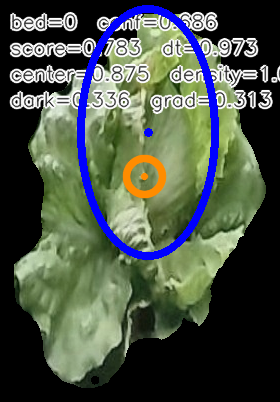

In [ ]:
pred, overlay_img = handle_overlay_input("10번째 이미지를 분석하고 결구를 표시해줘")


In [ ]:

# =========================================================
# 셀 8. 사용 예시
# =========================================================
# pred, overlay_img = handle_overlay_input("5번째 이미지를 분석하고 결구를 표시해줘")
# pred, overlay_img = handle_overlay_input("엑셀 기준 5번째 이미지 결구 표시해줘")


# =========================================================
# 셀 9. 기존 while 루프에 넣고 싶을 때 참고용 조건문
# - 기존 대화 루프 전체를 갈아엎지 않고 추가할 수 있는 형태
# =========================================================
# 아래 블록을 기존 while True 내부, 일반 ask_model 호출 전에 넣으면 됨.
#
# overlay_keywords = ["결구를 표시", "결구 표시", "타원 표시", "박스 표시", "표시해줘"]
# if any(k in user_input for k in overlay_keywords) and is_nth_image_query(user_input):
#     handle_overlay_input(user_input)
#     continue


# =========================================================
# 셀 10. 여러 장 수동 테스트용
# =========================================================
# for q in [
#     "5번째 이미지를 분석하고 결구를 표시해줘",
#     "10번째 이미지 결구 표시해줘",
# ]:
#     print("\n===", q, "===")
#     handle_overlay_input(q)
